# What makes up Tampa's mapped bicycle network?

The City of Tampa calls this public ArcGIS layer **Bike Lanes**, but its connection codes also include shared roadways, paths, trails, and other links. This notebook asks a narrow question: **how does the mix change when we count mapped segments versus sum the source's reported mileage?**

We retrieve the *complete* layer at run time, check every returned object ID against the service's ID manifest, examine missing and zero values, and then compare connection classes. The saved outputs are one dated observation; rerunning the notebook fetches current publisher data.

**Source:** [City of Tampa layer and field definitions](https://arcgis.tampagov.net/arcgis/rest/services/OpenData/Transportation/MapServer/0) · [publisher item and reuse terms](https://tampa.maps.arcgis.com/home/item.html?id=d54aac9d4559488fa439e454df5f09ce). This is the `bike-lanes` entry in `tampaBayOpenData`'s checked catalog. In R, the analogous call is `tbod_get_dataset("bike-lanes", fields = c("OBJECTID", "CONN_TYPE", "MILEAGE", "ROADWAY"))`; this Python notebook queries that same public layer directly so it runs with a standard Jupyter Python kernel.

Run all cells with Python 3 and `requests`, `pandas`, `matplotlib`, and `IPython` installed. Network access to the City's ArcGIS service is required. No raw data file is bundled; the saved notebook contains a five-row preview and aggregate results from one live run.


In [1]:
from datetime import datetime, timezone
from io import BytesIO
import time

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
import requests
from IPython.display import Image, display
from requests.adapters import HTTPAdapter
from urllib3.util.retry import Retry

LAYER_URL = "https://arcgis.tampagov.net/arcgis/rest/services/OpenData/Transportation/MapServer/0"
QUERY_URL = f"{LAYER_URL}/query"
FIELDS = ["OBJECTID", "CONN_TYPE", "MILEAGE", "ROADWAY"]

session = requests.Session()
session.headers.update({"User-Agent": "tampaBayOpenData-bicycle-EDA/1.0"})
retry = Retry(
    total=3,
    backoff_factor=0.5,
    status_forcelist=[429, 500, 502, 503, 504],
    allowed_methods=frozenset(["GET", "POST"]),
)
session.mount("https://", HTTPAdapter(max_retries=retry))


def arcgis_json(method, url, **kwargs):
    '''Read one ArcGIS JSON response and surface service errors.'''
    for attempt in range(3):
        response = session.request(method, url, timeout=45, **kwargs)
        response.raise_for_status()
        payload = response.json()
        error = payload.get("error")
        if error is None:
            return payload
        # A few ArcGIS services return intermittent query error 400 in HTTP 200.
        if not (url == QUERY_URL and error.get("code") == 400 and attempt < 2):
            raise RuntimeError(f"ArcGIS error {error.get('code')}: {error.get('message')}")
        time.sleep(0.5 * (attempt + 1))
    raise RuntimeError("ArcGIS query did not succeed after retries")


## 1. Inspect the live schema and count the layer

The City's `CONN_TYPE` coded-value domain supplies the category names. We record the publisher's count and complete object-ID manifest before requesting records. If they disagree, the source may have changed during the run and the analysis stops.


In [2]:
layer = arcgis_json("GET", LAYER_URL, params={"f": "json"})
source_fields = {field["name"]: field for field in layer["fields"]}
missing_fields = sorted(set(FIELDS) - set(source_fields))
if missing_fields:
    raise RuntimeError(f"Source fields changed: {missing_fields}")
if "Query" not in layer.get("capabilities", "").split(","):
    raise RuntimeError("The layer no longer advertises Query capability")

domain = source_fields["CONN_TYPE"].get("domain") or {}
code_to_name = {
    str(item["code"]): str(item["name"]).strip()
    for item in domain.get("codedValues", [])
}
count = arcgis_json(
    "GET", QUERY_URL, params={"f": "json", "where": "1=1", "returnCountOnly": "true"}
)["count"]
manifest = arcgis_json(
    "GET", QUERY_URL, params={"f": "json", "where": "1=1", "returnIdsOnly": "true"}
)
object_ids = sorted(int(value) for value in (manifest.get("objectIds") or []))
if count != len(object_ids) or len(object_ids) != len(set(object_ids)):
    raise RuntimeError("Count and object-ID manifest disagree; rerun against a stable source")

print(f"Layer: {layer['name']} | Records reported: {count:,} | Unique IDs: {len(object_ids):,}")
print(f"Source maximum page size: {layer.get('maxRecordCount', 'unknown')}")
display(pd.DataFrame(
    [{"code": code, "publisher_label": name} for code, name in code_to_name.items()]
))


Layer: Bike Lanes | Records reported: 6,858 | Unique IDs: 6,858
Source maximum page size: 2000


,code,publisher_label
0,DC,Difficult Connection
1,TR,Trail
2,NG,Neighborhood Greenway
3,SC,Sidewalk Connection
4,SR_LT_LS,Shared Roadway (Low Stress)
5,SR_MHT_LS,Shared Roadway (Moderate Stress)
6,SR_LT_HS,Shared Roadway (High Stress)
7,BL_HT_HS,Bike Lane (High Stress)
8,SBL_LT_LS,Bike Lane (Separated and/or Low Stress)
9,MUP,Multi-Use Path


## 2. Retrieve every segment and check completeness

The request uses bounded object-ID batches below the service's page limit. We compare returned IDs with the initial manifest, check for duplicates and transfer-limit flags, then recheck the count and ID manifest after retrieval. A change in record membership causes a visible error instead of an incomplete chart.


In [3]:
batch_size = min(500, int(layer.get("maxRecordCount") or 500))
records = []
for start in range(0, len(object_ids), batch_size):
    batch = object_ids[start : start + batch_size]
    payload = arcgis_json(
        "POST",
        QUERY_URL,
        data={
            "f": "json",
            "objectIds": ",".join(map(str, batch)),
            "outFields": ",".join(FIELDS),
            "returnGeometry": "false",
        },
    )
    if payload.get("exceededTransferLimit"):
        raise RuntimeError(f"Transfer limit reached for batch beginning at {start}")
    records.extend(feature["attributes"] for feature in payload.get("features", []))

retrieved_at = datetime.now(timezone.utc)
segments = pd.DataFrame.from_records(records, columns=FIELDS)
segments["OBJECTID"] = pd.to_numeric(segments["OBJECTID"], errors="raise").astype("int64")
segments["MILEAGE"] = pd.to_numeric(segments["MILEAGE"], errors="coerce")
returned_ids = segments["OBJECTID"].tolist()
if (len(returned_ids) != count or len(returned_ids) != len(set(returned_ids))
        or set(returned_ids) != set(object_ids)):
    raise RuntimeError("Returned records do not match the full ID manifest; rerun")
post_count = arcgis_json(
    "GET", QUERY_URL, params={"f": "json", "where": "1=1", "returnCountOnly": "true"}
)["count"]
post_manifest = arcgis_json(
    "GET", QUERY_URL, params={"f": "json", "where": "1=1", "returnIdsOnly": "true"}
)
if post_count != count or set(post_manifest.get("objectIds") or []) != set(object_ids):
    raise RuntimeError("Source record membership changed during retrieval; rerun")
segments = segments.sort_values("OBJECTID").reset_index(drop=True)

provenance = {
    "publisher": "City of Tampa",
    "catalog_id": "bike-lanes",
    "layer_url": LAYER_URL,
    "retrieved_at_utc": retrieved_at.isoformat(timespec="seconds"),
    "matched_rows": count,
    "returned_rows": len(segments),
    "complete": True,
    "method": "count + pre/post full ID manifests + bounded ID batches",
}
display(pd.DataFrame([provenance]).T.rename(columns={0: "value"}))
display(segments.head())


,value
publisher,City of Tampa
catalog_id,bike-lanes
layer_url,https://arcgis.tampagov.net/arcgis/rest/servic...
retrieved_at_utc,2026-10-06T22:27:36+00:00
matched_rows,6858
returned_rows,6858
complete,True
method,count + pre/post full ID manifests + bounded I...


,OBJECTID,CONN_TYPE,MILEAGE,ROADWAY
0,2059258,SR_LT_LS,0.02373,Lincoln Ave
1,2059259,BL_HT_HS,0.02618,Dale Mabry Hwy
2,2059260,SR_LT_LS,0.05803,20th St
3,2059261,SR_LT_HS,0.00662,Lake Ave
4,2059262,BL_HT_HS,0.04779,40th St


## 3. Check what the fields can support

One record is one mapped line segment, **not** necessarily one route. `MILEAGE` is a publisher-supplied attribute. A zero may mean an unmeasured connector or a rounded value; its exact meaning is unclear. We preserve these rows for segment counts and flag them before interpreting summed mileage. Blank or `N/A` roadway labels are also counted.


In [4]:
unknown_codes = sorted(set(segments["CONN_TYPE"].dropna()) - set(code_to_name))
roadway_labels = segments["ROADWAY"].fillna("").astype(str).str.strip()
quality = pd.DataFrame(
    [
        ("Returned segments", len(segments)),
        ("Missing connection code", int(segments["CONN_TYPE"].isna().sum())),
        ("Codes absent from current metadata", len(unknown_codes)),
        ("Missing reported mileage", int(segments["MILEAGE"].isna().sum())),
        ("Zero reported mileage", int(segments["MILEAGE"].eq(0).sum())),
        ("Negative reported mileage", int(segments["MILEAGE"].lt(0).sum())),
        ("Blank or N/A roadway label", int(roadway_labels.isin(["", "NA", "N/A"]).sum())),
    ],
    columns=["check", "value"],
)
display(quality)
if unknown_codes:
    print("Unknown codes:", unknown_codes)
if segments["MILEAGE"].lt(0).any():
    raise RuntimeError("Negative mileage needs review before aggregation")

segments["connection"] = segments["CONN_TYPE"].map(code_to_name).fillna(
    segments["CONN_TYPE"].fillna("Unclassified")
)
class_summary = (
    segments.groupby(["CONN_TYPE", "connection"], dropna=False)
    .agg(segments=("OBJECTID", "size"), reported_miles=("MILEAGE", "sum"),
         zero_mile_segments=("MILEAGE", lambda values: int(values.eq(0).sum())))
    .reset_index()
    .sort_values("reported_miles", ascending=False)
)
display(class_summary.round({"reported_miles": 2}))


,check,value
0,Returned segments,6858
1,Missing connection code,0
2,Codes absent from current metadata,0
3,Missing reported mileage,0
4,Zero reported mileage,236
5,Negative reported mileage,0
6,Blank or N/A roadway label,7


,CONN_TYPE,connection,segments,reported_miles,zero_mile_segments
7,SR_LT_LS,Shared Roadway (Low Stress),2987,203.98,1
0,BL_HT_HS,Bike Lane (High Stress),1371,82.54,0
2,MUP,Multi-Use Path,423,75.74,88
6,SR_LT_HS,Shared Roadway (High Stress),672,39.66,0
4,SBL_LT_LS,Bike Lane (Separated and/or Low Stress),480,25.84,0
8,SR_MHT_LS,Shared Roadway (Moderate Stress),253,18.92,1
3,NG,Neighborhood Greenway,290,15.99,0
1,DC,Difficult Connection,217,12.31,0
9,TR,Trail,19,1.10,0
5,SC,Sidewalk Connection,146,0.00,146


## 4. Compare segment counts with reported mileage

For a short summary, we group the City's ten codes into four transparent families. These are analytical labels for this notebook, not a replacement for the publisher's codes: shared roadway (`SR_*`), bike-lane categories (`BL_HT_HS`, `SBL_LT_LS`), paths and trails (`MUP`, `TR`), and other connections (`DC`, `NG`, `SC`). Any new code remains in `Other or new code` so it cannot disappear silently.


,segments,reported_miles,segment_share_pct,mileage_share_pct
family,,,,
Shared roadway,3912,262.56,57.04,55.15
Bike-lane categories,1851,108.38,26.99,22.77
Other connections,653,28.30,9.52,5.94
Paths and trails,442,76.84,6.45,16.14


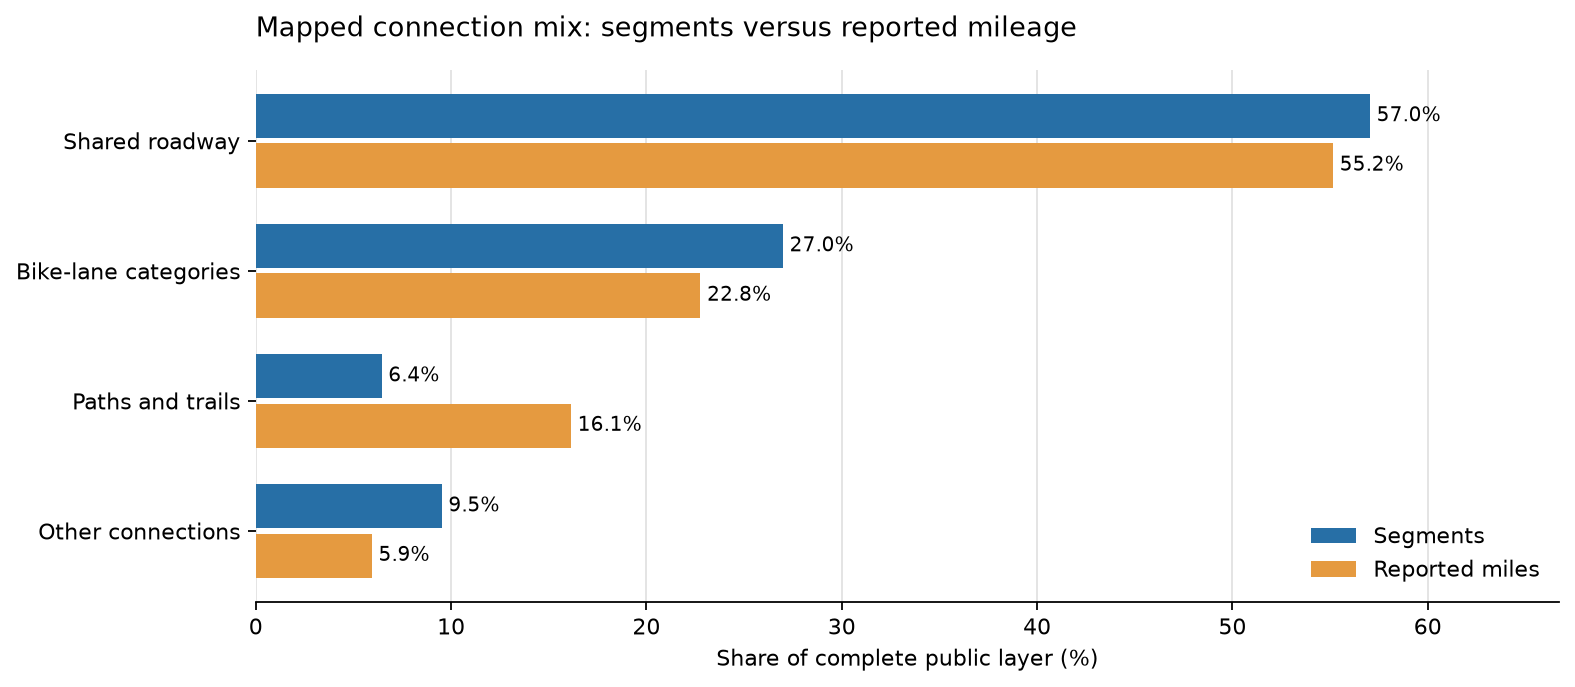

In [5]:
family_by_code = {
    "SR_LT_LS": "Shared roadway", "SR_MHT_LS": "Shared roadway", "SR_LT_HS": "Shared roadway",
    "BL_HT_HS": "Bike-lane categories", "SBL_LT_LS": "Bike-lane categories",
    "MUP": "Paths and trails", "TR": "Paths and trails",
    "DC": "Other connections", "NG": "Other connections", "SC": "Other connections",
}
segments["family"] = segments["CONN_TYPE"].map(family_by_code).fillna("Other or new code")
family = (
    segments.groupby("family", dropna=False)
    .agg(segments=("OBJECTID", "size"), reported_miles=("MILEAGE", "sum"))
    .sort_values("segments", ascending=False)
)
family["segment_share_pct"] = 100 * family["segments"] / len(segments)
family["mileage_share_pct"] = 100 * family["reported_miles"] / segments["MILEAGE"].sum()
display(family.round(2))

family_order = ["Shared roadway", "Bike-lane categories", "Paths and trails", "Other connections", "Other or new code"]
plot_families = family.reindex([name for name in family_order if name in family.index])
y = list(range(len(plot_families)))
fig, ax = plt.subplots(figsize=(10, 4.4))
count_bars = ax.barh([v - 0.19 for v in y], plot_families["segment_share_pct"],
                     height=0.34, color="#276fa6", label="Segments")
mile_bars = ax.barh([v + 0.19 for v in y], plot_families["mileage_share_pct"],
                    height=0.34, color="#e59a40", label="Reported miles")
ax.set_yticks(y, plot_families.index)
ax.invert_yaxis()
ax.set_xlim(0, max(plot_families[["segment_share_pct", "mileage_share_pct"]].max()) * 1.17)
ax.set_xlabel("Share of complete public layer (%)")
ax.set_title("Mapped connection mix: segments versus reported mileage", loc="left", pad=15)
ax.grid(axis="x", color="#dddddd", linewidth=0.7)
ax.set_axisbelow(True)
ax.legend(frameon=False, loc="lower right")
for bars in (count_bars, mile_bars):
    ax.bar_label(bars, labels=[f"{bar.get_width():.1f}%" for bar in bars], padding=3, fontsize=9)
for spine in ("top", "right", "left"):
    ax.spines[spine].set_visible(False)
fig.tight_layout()
buffer = BytesIO()
fig.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
display(Image(data=buffer.getvalue()))
plt.close(fig)


## 5. Inspect the zero-mileage exception

The first chart is an inventory comparison, not a measured network-length estimate. This check shows which publisher classes contribute zero `MILEAGE` values. In particular, a zero-mileage class must remain visible in the segment chart even though its reported-mile share is zero.


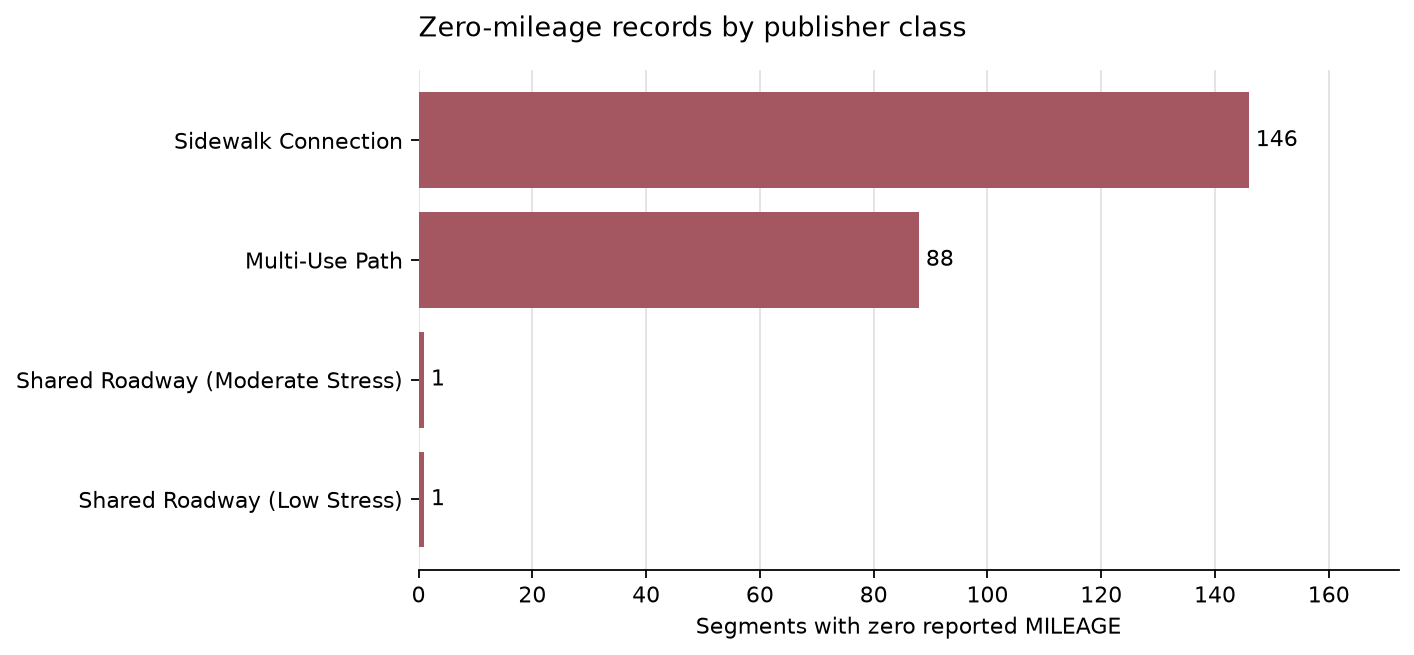

As of 2026-10-06 22:27 UTC, this complete public layer contains 6,858 segments with 476.07 summed reported miles.
Shared-roadway codes account for 57.0% of segments and 55.2% of reported miles; bike-lane codes account for 27.0% and 22.8%, respectively.
236 segments report zero miles, so the mileage totals should be read as source attributes rather than independently measured route length.


In [6]:
zero_plot = class_summary[class_summary["zero_mile_segments"] > 0].sort_values("zero_mile_segments")
if len(zero_plot):
    fig, ax = plt.subplots(figsize=(9, max(2.8, 0.65 * len(zero_plot) + 1.6)))
    bars = ax.barh(zero_plot["connection"], zero_plot["zero_mile_segments"], color="#a45760")
    ax.set_xlim(0, max(zero_plot["zero_mile_segments"]) * 1.18)
    ax.set_xlabel("Segments with zero reported MILEAGE")
    ax.set_title("Zero-mileage records by publisher class", loc="left", pad=15)
    ax.grid(axis="x", color="#dddddd", linewidth=0.7)
    ax.set_axisbelow(True)
    ax.bar_label(bars, padding=3)
    for spine in ("top", "right", "left"):
        ax.spines[spine].set_visible(False)
    fig.tight_layout()
    buffer = BytesIO()
    fig.savefig(buffer, format="png", dpi=160, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)
else:
    print("No zero-mileage segments in this run.")

shared = family.loc["Shared roadway"]
bike_lanes = family.loc["Bike-lane categories"]
print(
    f"As of {retrieved_at:%Y-%m-%d %H:%M UTC}, this complete public layer contains "
    f"{len(segments):,} segments with {segments['MILEAGE'].sum():,.2f} summed reported miles."
)
print(
    f"Shared-roadway codes account for {shared['segment_share_pct']:.1f}% of segments and "
    f"{shared['mileage_share_pct']:.1f}% of reported miles; bike-lane codes account for "
    f"{bike_lanes['segment_share_pct']:.1f}% and {bike_lanes['mileage_share_pct']:.1f}%, respectively."
)
print(
    f"{segments['MILEAGE'].eq(0).sum():,} segments report zero miles, so the mileage totals "
    "should be read as source attributes rather than independently measured route length."
)


## What this does and does not show

The layer's name covers more than dedicated bike lanes: the City's own connection classes include shared roadways, greenways, paths, trails, sidewalk connections, and difficult connections. Counting features gives each mapped segment one vote; summing `MILEAGE` gives longer segments more weight. Neither measure establishes usable route miles, current condition, rider safety, or geographic access. The City's stress labels are source classifications, not safety findings from this notebook.

The public service can change between runs. The pre/post manifest checks guard against missing, duplicate, or changed record membership during this pull, but they cannot freeze attributes while the publisher edits them. The service labels the field `MILEAGE`; its values were not remeasured from geometry, and overlapping alignments may be counted more than once. For reuse terms and detailed scope, inspect the [publisher item](https://tampa.maps.arcgis.com/home/item.html?id=d54aac9d4559488fa439e454df5f09ce) and `tbod_dataset_info("bike-lanes")` in the R package.
